✅ Modèle chargé avec succès


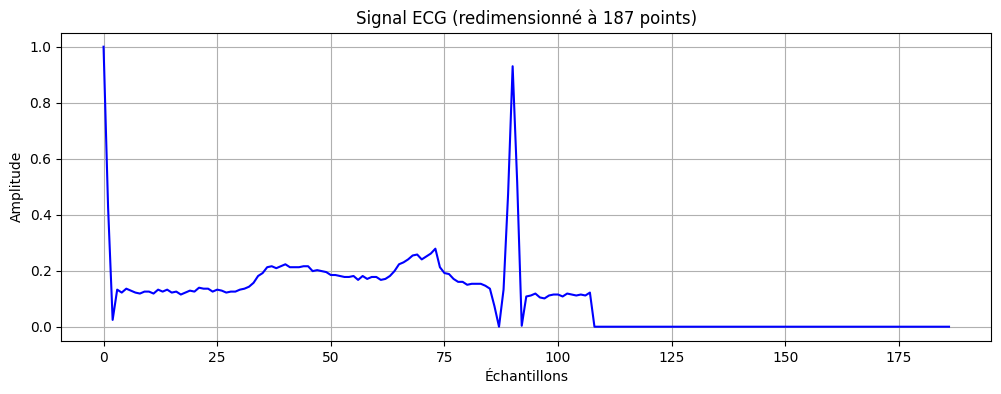

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
🧠 Classe prédite : 0


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from keras.models import load_model

# === Charger le modèle ===
model_path = r"C:\Users\21629\Desktop\PFE\modéle (CNN) 1D basée aal mitbih\CNN 1D model.h5"
model = load_model(model_path)
print("✅ Modèle chargé avec succès")

# === Charger le signal depuis le fichier CSV ===
signal_path = r"C:\Users\21629\Desktop\PFE\extraire signal à partir du dataset\signal_unique70000000000000.csv"
df_signal = pd.read_csv(signal_path, header=None)

# Récupérer les valeurs du signal
if df_signal.shape[0] == 1:
    signal = df_signal.iloc[0].values
else:
    signal = df_signal.iloc[:, 0].values

# === Ajuster la taille du signal à 187 points ===
target_length = 187
if len(signal) > target_length:
    signal = signal[:target_length]  # tronquer
elif len(signal) < target_length:
    # Compléter avec des zéros (padding)
    padding = target_length - len(signal)
    signal = np.pad(signal, (0, padding), mode='constant')
    
# === Afficher le signal ECG ===
plt.figure(figsize=(12, 4))
plt.plot(signal, color='blue')
plt.title("Signal ECG (redimensionné à 187 points)")
plt.xlabel("Échantillons")
plt.ylabel("Amplitude")
plt.grid()
plt.show()

# === Normaliser le signal ===
signal = (signal - np.min(signal)) / (np.max(signal) - np.min(signal) + 1e-6)

# === Préparer le signal pour le modèle ===
signal_input = np.expand_dims(signal, axis=(0, 2))  # shape: (1, 187, 1)

# === Prédiction ===
prediction = model.predict(signal_input)
predicted_class = np.argmax(prediction, axis=-1)[0]

print(f"🧠 Classe prédite : {predicted_class}")
